<a href="https://colab.research.google.com/github/devKarthikeyanR/Agentic_AI_Learnings_Reflection/blob/main/Learning_Reflection/ReAct_Learning_Reflection_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ReAct : Reasoning and Action with multi tool set.**
---

**What i learnt.**

* ReAct Loop (Reason + Act)
* Tools `Functions`
   * (Tool Desription / Doc String and Arguments Description)
* Runtime Context
* System Prompt
* `Messages` (Tool, AI, Human and System Message)
* Agent Run Types **`invoke` vs `stream`**
   * **`invoke`** Run and wait for the final answer
   * **`stream`** Run and get output step by step as it happens

   * **Stream Modes** `values` gives Every step , `custom` gives tools specific, and `messages` gives token by token


**Question 1:** Does a `Agent` rely ONLY on the `tool's docstring/description`
to select the right tool, or does it also consider the tool's name and
internal logic? I built a `calculator agent` where I purposefully swapped the docstrings
between two tools, but the `agent` still picked the correct tool.
This made me think the agent looks beyond just the docstring. What exactly does the LLM use to decide which tool to call?





---
>**ReAct** Problem: Movie Ticket Booking Agent with multi tools set.



In [ ]:
!pip install -qU langchain-groq langgraph langchain-community pysqlite3-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.5/167.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
langchain 1.2.10 requires langgraph<1.1.0,>=1.0.8, but you have langgraph 1.1.2 which is incompati

In [ ]:
from google.colab import userdata
import os

os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

>Downloading the Database to the workspace

In [ ]:
from langchain_community.utilities import SQLDatabase

# Use raw URL to get the actual file
!wget -q "https://raw.githubusercontent.com/devKarthikeyanR/Agentic_AI_Learnings_Reflection/main/Database/theatre_management_system_db.db"



>Connecting to the Database

In [ ]:
# Connect to it
db = SQLDatabase.from_uri("sqlite:///theatre_management_system_db.db")

# Verify connection
print(db.get_usable_table_names())

['bookings', 'movies', 'screenings', 'screens', 'seats']


> Runtime Context

In [ ]:
from dataclasses import dataclass
from langchain_community.utilities import SQLDatabase

@dataclass
class RuntimeContext:
    db: SQLDatabase

>Tools Definition

In [ ]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime
from datetime import date

@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

'''
@tool
def get_movies(genre: str = "", rating: str ="", screening_date: date = None) -> str:
    """Get all movies screening for a given date.
    Optionally filter by genre (if no genre given then get all genre). If no date given, defaults to today.
    Args:
    Screening Date: {screening_date}
    Genre: {genre}
    rating: {rating}
    """
    return get_movies.__doc__
'''

@tool
def get_movies(genre: str = "", rating: str = "", screening_date: date = None) -> str:
    """Get all movies screening for a given date.
    Optionally filter by genre (if no genre given then get all genres).
    If no date given, defaults to today.
    If no arguments passed, return all the movies list.
    Args:
        screening_date: Date to check screenings (default: today)
        genre: Movie genre to filter by (default: all genres)
        rating: Movie rating to filter by e.g. U, U/A (default: all ratings)
    """

    target_date = screening_date or date.today()

    return f"Received - Date: {target_date}, Genre: {genre or 'All'}, Rating: {rating or 'All'} : {get_movies.__doc__}"

@tool
def get_bookings(title: str = "", screening_date: date = None) -> str:
    """Get all bookings for a given movie and date.
    If no movie name given, returns bookings for all movies.
    If no date given, defaults to today.
    Args:
        title: Name of the movie to filter bookings (default: all movies)
        screening_date: Date to filter bookings (default: today)
    """
    return f"title: {title}, Screnning Date: {screening_date} : {get_bookings.__doc__}"

@tool
def get_available_seats(title: str = "", screening_date: date = None) -> str:
    """Get all available seats for a given movie and date.
    If no movie name given, returns available seats for all movies.
    If no date given, defaults to today.
    Args:
        title: Name of the movie to check available seats (default: all movies)
        screening_date: Date to check available seats (default: today)
    """
    return f"title: {title}, Screening Date: {screening_date} : {get_available_seats.__doc__}"

@tool
def book_movie_ticket(title: str, seat_number: str, customer_name: str,
                      customer_phone: str, screening_date: date = None) -> str:
    """Book a movie ticket for a customer for a given movie and seat.
    Checks seat availability before confirming the booking.
    If no date given, defaults to today.
    Args:
        movie_name: Name of the movie to book the ticket for
        seat_number: Seat number to book e.g. A1, B5, G3
        customer_name: Full name of the customer
        customer_phone: Phone number of the customer
        screening_date: Date of the screening to book (default: today)
    """
    return f"title: {title}, Seat: {seat_number}, Customer: {customer_name}, Phone: {customer_phone}, Date: {screening_date} : {book_movie_ticket.__doc__}"


>System Prompt

In [ ]:
SYSTEM_PROMPT = """
You are a movie ticket booking assistant for Karthikeyan Cinemas, Bengaluru.
Help customers book tickets, check movie listings, and view their bookings.

## Tools Available
- get_movies: Get movies currently screening, Get show times and ticket prices for a movie
- get_available_seats: Check available seats for a screening
- book_movie_ticket: Book a ticket for a customer
- get_bookings: Get existing bookings for a customer
- execute_sql: to get information about running movies, available seats, to book ticket, get bookings, you will use this connect to the DB in the backend.

## Rules
- You only know the tools and runtime context and no outside data.
- Always check available seats before booking
- Always confirm movie, show time, seat, and price with the customer before booking
- Collect customer name and phone number before calling book_movie_ticket
- If a seat or show is unavailable, suggest alternatives
- For changes or cancellations, ask the customer to visit the counter

## Booking Flow
1. ALWAYS call get_movies first to fetch current screenings and show the list to the customer
2. Ask for movie preference and show time
3. Check available seats using get_available_seats
4. Confirm movie, show time, seat and price with customer
5. Collect customer name and phone number
6. Book the ticket and share the Booking ID
7. You know how to write a sql query to query our theatre database. (Before executing actual query understand the schema of the table)

## Database Table Details
 - movies: lists all films currently screening
 - screens: lists all the screens available in the theatre
 - seats: seat details as per the screens
 - screenings: lists different screens and times
 - bookings: booking details are kept here.

Keep responses short and friendly.
"""

>Creating the agent with tools defined

In [ ]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq

# Initialize the LLM
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    max_retries=2,
)

toolset = [book_movie_ticket, get_available_seats, get_bookings, get_movies, execute_sql]

# Create the agent
agent = create_agent(
    model=llm,
    tools=toolset,
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

>Generate the grapgh to understand how Agent is coupled.

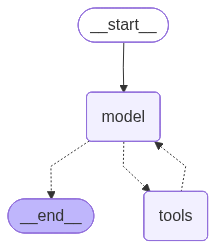

In [ ]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

>**ReAct** : Execution of the Agent

In [ ]:
question = "Would like to book a movie ticket to watch along with my family"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Would like to book a movie ticket to watch along with my family
================================== Ai Message ==================================
Tool Calls:
  get_movies (fc_49650c06-0b77-4349-a717-00c64fa6352a)
 Call ID: fc_49650c06-0b77-4349-a717-00c64fa6352a
  Args:
================================= Tool Message =================================
Name: get_movies

Received - Date: 2026-03-14, Genre: All, Rating: All : Tool that can operate on any number of inputs.
================================== Ai Message ==================================
Tool Calls:
  get_movies (fc_500845c4-c118-4cea-846d-b7fb0ed69bc9)
 Call ID: fc_500845c4-c118-4cea-846d-b7fb0ed69bc9
  Args:
================================= Tool Message =================================
Name: get_movies

Received - Date: 2026-03-14, Genre: All, Rating: All : Tool that can operate on any number of inputs.
================================== Ai Me

>**ReAct** : Agent understands the query, does the reasoning on its own.

In [ ]:
question = "I have a kid who is less than 5 years old, what movies are allowed"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

I have a kid who is less than 5 years old, what movies are allowed
================================== Ai Message ==================================
Tool Calls:
  get_movies (fc_fd4edde3-2659-451f-b1d4-544ac25f0b7e)
 Call ID: fc_fd4edde3-2659-451f-b1d4-544ac25f0b7e
  Args:
    rating: U
================================= Tool Message =================================
Name: get_movies

Received - Date: 2026-03-14, Genre: All, Rating: U : Tool that can operate on any number of inputs.
================================== Ai Message ==================================
Tool Calls:
  get_movies (fc_2219504f-c6c0-4b4e-8abd-6de11f623f46)
 Call ID: fc_2219504f-c6c0-4b4e-8abd-6de11f623f46
  Args:
    rating: U
================================= Tool Message =================================
Name: get_movies

Received - Date: 2026-03-14, Genre: All, Rating: U : Tool that can operate on any number of inputs.
=============